## Hands-On Data Preprocessing in Python
Learn how to effectively prepare data for successful data analytics
    
    AUTHOR: Dr. Roy Jafari 

### Chapter 5: Data Visualization 
#### Excercises

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from ipywidgets import interact, widgets


# Excercise 1
In this exercise, we will be using Universities_imputed_reduced.csv. Draw the following described visualizations.

    a.	Use boxplots to compare the student to faculty ratio (stud./fac. ratio) for the two population public and private universities.
    b.	Use a histogram to compare the student to faculty ratio (stud./fac. ratio) for the two population public and private universities.
    c.	use subplots to put the results of a and b on top of one another to create a visual that compares the two populations even better. 


In [3]:
uni_df = pd.read_csv('Universities_imputed_reduced.csv')
uni_df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Universities_imputed_reduced.csv'

a. 

<Figure size 600x500 with 0 Axes>

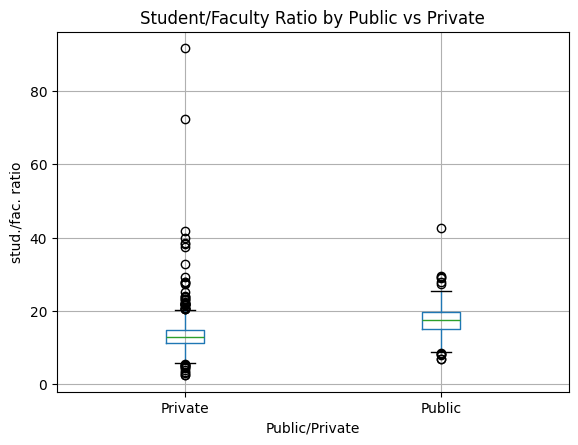

In [ ]:
# a. Boxplot: stud./fac. ratio for Public vs Private
plt.figure(figsize=(6,5))
uni_df.boxplot(column='stud./fac. ratio', by='Public/Private')
plt.title('Student/Faculty Ratio by Public vs Private')
plt.suptitle('')
plt.ylabel('stud./fac. ratio')
plt.show()


b. 

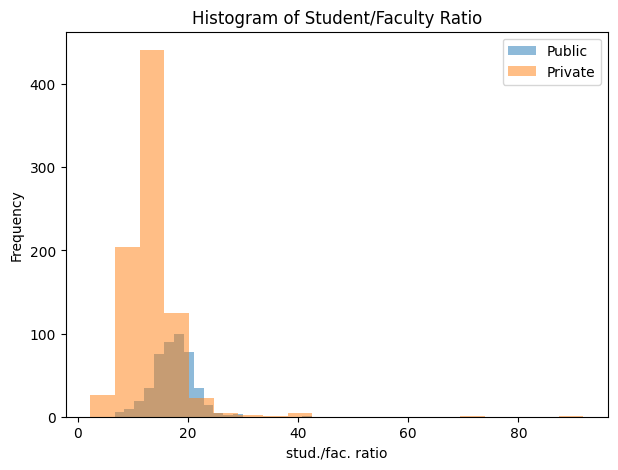

In [ ]:
# b. Histogram: stud./fac. ratio for Public vs Private
plt.figure(figsize=(7,5))
uni_df[uni_df['Public/Private']=='Public']['stud./fac. ratio'].plot.hist(alpha=0.5, bins=20, label='Public')
uni_df[uni_df['Public/Private']=='Private']['stud./fac. ratio'].plot.hist(alpha=0.5, bins=20, label='Private')
plt.xlabel('stud./fac. ratio')
plt.legend()
plt.title('Histogram of Student/Faculty Ratio')
plt.show()


c. 

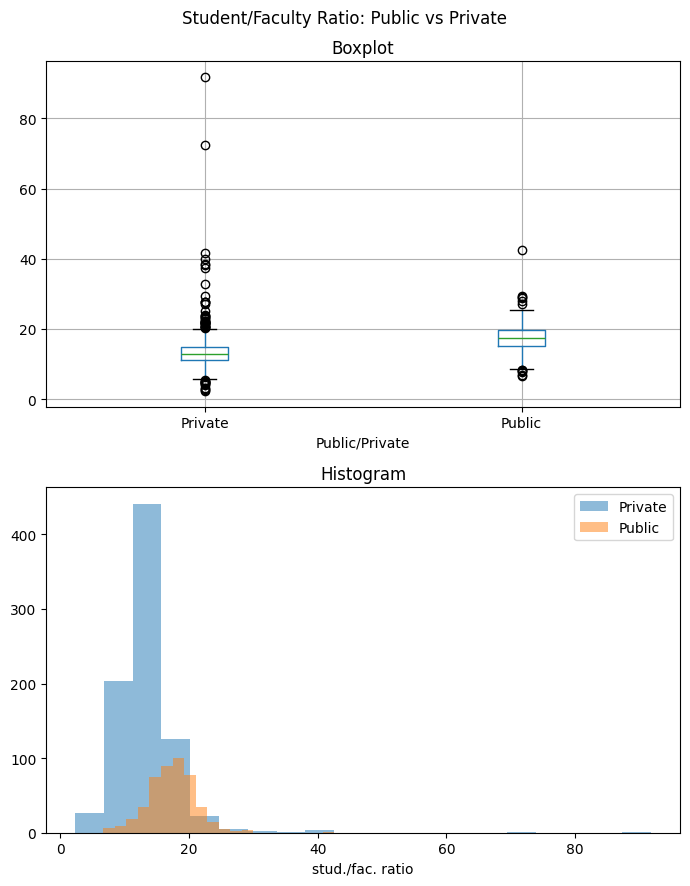

In [ ]:
# c. Combine a) and b) using subplots
fig, axes = plt.subplots(2, 1, figsize=(7,9))

uni_df.boxplot(column='stud./fac. ratio', by='Public/Private', ax=axes[0])
axes[0].set_title('Boxplot')

for label, grp in uni_df.groupby('Public/Private'):
    axes[1].hist(grp['stud./fac. ratio'], alpha=0.5, bins=20, label=label)
axes[1].legend()
axes[1].set_title('Histogram')
axes[1].set_xlabel('stud./fac. ratio')

plt.suptitle('Student/Faculty Ratio: Public vs Private')
plt.tight_layout()
plt.show()


# Excercise 2

In this exercise, we will continue using Universities_imputed_reduced.csv. Draw the following described visualizations.

    a.	Use a bar chart to compare the private/public ratio of all the states in the dataset. In this example, the populations we are comparing are the states. 
    b.	Improve the visualizations by sorting the states on the visuals based on the total number of universities they have.
    c.	Create a stacked bar chart that shows the compare the percentages of public and private schools across different states. 

a.

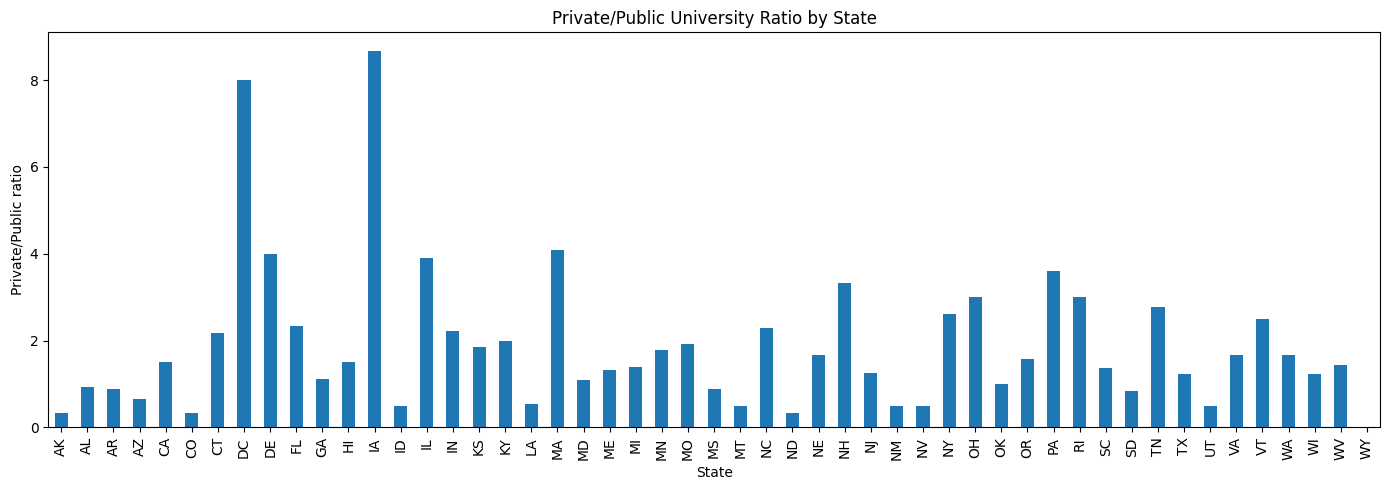

In [ ]:
# a. Bar chart: Private/Public ratio per state
state_counts = uni_df.groupby(['State', 'Public/Private']).size().unstack(fill_value=0)
ratio = state_counts['Private'] / state_counts['Public'].replace(0, np.nan)

plt.figure(figsize=(14,5))
ratio.plot.bar()
plt.ylabel('Private/Public ratio')
plt.title('Private/Public University Ratio by State')
plt.tight_layout()
plt.show()


b.

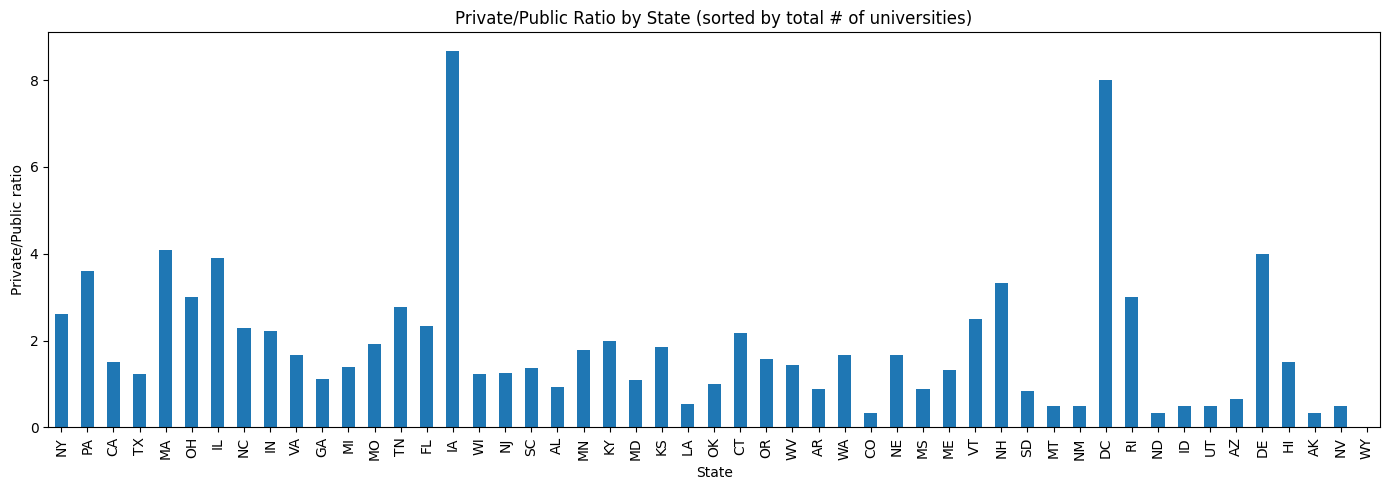

In [ ]:
# b. Same chart, sorted by total number of universities per state
state_counts['total'] = state_counts['Private'] + state_counts['Public']
order = state_counts.sort_values('total', ascending=False).index
ratio_sorted = ratio[order]

plt.figure(figsize=(14,5))
ratio_sorted.plot.bar()
plt.ylabel('Private/Public ratio')
plt.title('Private/Public Ratio by State (sorted by total # of universities)')
plt.tight_layout()
plt.show()


c.

<Figure size 1400x500 with 0 Axes>

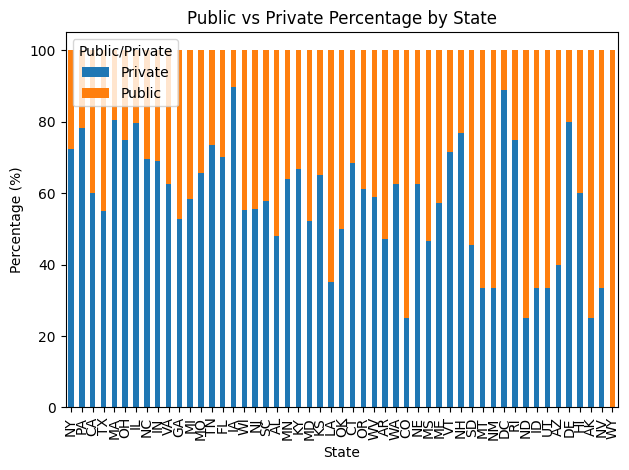

In [ ]:
# c. Stacked bar chart: % public vs % private per state
pct = state_counts[['Private', 'Public']].div(state_counts[['Private','Public']].sum(axis=1), axis=0) * 100
pct = pct.loc[order]

plt.figure(figsize=(14,5))
pct.plot.bar(stacked=True)
plt.ylabel('Percentage (%)')
plt.title('Public vs Private Percentage by State')
plt.tight_layout()
plt.show()


# Excercise 3

For this example, we will be using WH Report_preprocessed.csv. Draw the following described visualizations.

    a.	Create a visual that compares the relationship between all the happiness indices.
    b.	Use the visual you created in a) to report the happiness indices with strong relationships, and describe those relationships.
    c.	Confirm the relationship you found and described by calculating their correlation coefficients and adding these new pieces of information to your description to improve them. 


In [ ]:
report_df = pd.read_csv('WH Report_preprocessed.csv')

a.

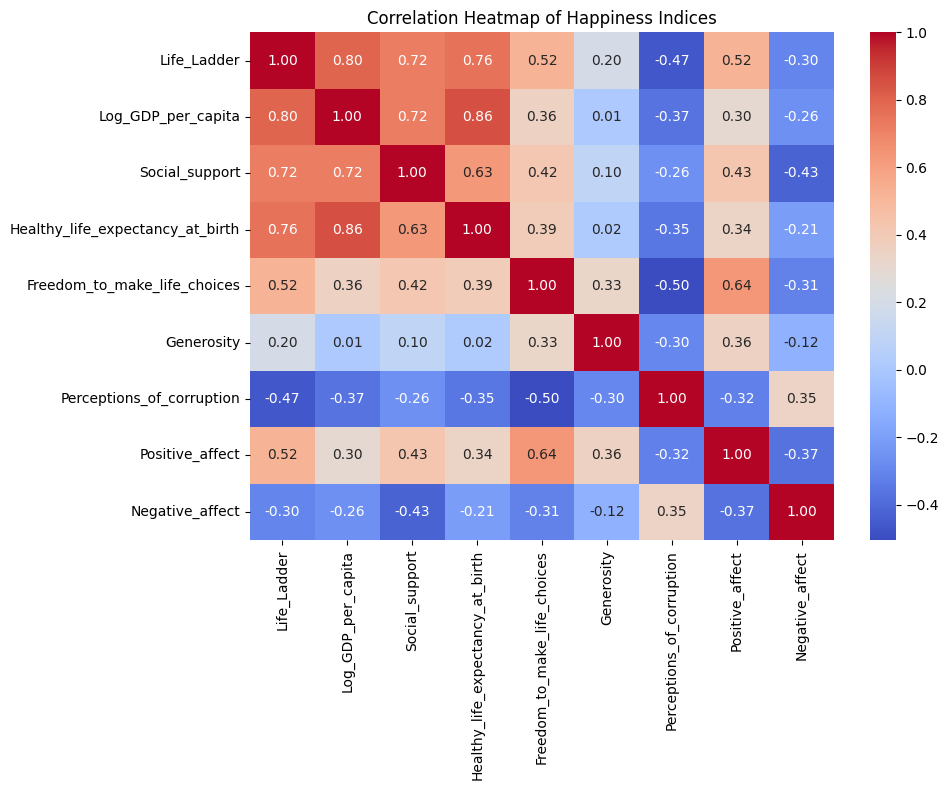

In [ ]:
# a. Relationship between all happiness indices -> correlation heatmap
num_cols = ['Life_Ladder','Log_GDP_per_capita','Social_support',
            'Healthy_life_expectancy_at_birth','Freedom_to_make_life_choices',
            'Generosity','Perceptions_of_corruption','Positive_affect','Negative_affect']

corr = report_df[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Happiness Indices')
plt.tight_layout()
plt.show()


b. 

In [ ]:
# b. Report the strongest relationships found in the heatmap
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().sort_values(ascending=False)
print(corr_pairs.head(8))

print("""
Strongest relationships visible in the heatmap:
- Log_GDP_per_capita  &  Healthy_life_expectancy_at_birth  -> strong positive
- Life_Ladder  &  Log_GDP_per_capita                        -> strong positive
- Life_Ladder  &  Healthy_life_expectancy_at_birth           -> strong positive
- Life_Ladder  &  Social_support                             -> strong positive
Richer countries (higher GDP) tend to have longer healthy life expectancy, and both
wealth and health strongly track how happy people report being (Life_Ladder).
""")


Log_GDP_per_capita            Healthy_life_expectancy_at_birth    0.857981
Life_Ladder                   Log_GDP_per_capita                  0.798912
                              Healthy_life_expectancy_at_birth    0.758287
                              Social_support                      0.723686
Log_GDP_per_capita            Social_support                      0.718969
Freedom_to_make_life_choices  Positive_affect                     0.635665
Social_support                Healthy_life_expectancy_at_birth    0.629507
Life_Ladder                   Freedom_to_make_life_choices        0.518618
dtype: float64

Strongest relationships visible in the heatmap:
- Log_GDP_per_capita  &  Healthy_life_expectancy_at_birth  -> strong positive
- Life_Ladder  &  Log_GDP_per_capita                        -> strong positive
- Life_Ladder  &  Healthy_life_expectancy_at_birth           -> strong positive
- Life_Ladder  &  Social_support                             -> strong positive
Richer countries (h

c.

In [ ]:
# c. Confirm the relationships with exact correlation coefficients
pairs_to_confirm = [
    ('Log_GDP_per_capita', 'Healthy_life_expectancy_at_birth'),
    ('Life_Ladder', 'Log_GDP_per_capita'),
    ('Life_Ladder', 'Healthy_life_expectancy_at_birth'),
    ('Life_Ladder', 'Social_support'),
]
for a, b in pairs_to_confirm:
    print(f"{a} vs {b}: r = {corr.loc[a, b]:.3f}")


Log_GDP_per_capita vs Healthy_life_expectancy_at_birth: r = 0.858
Life_Ladder vs Log_GDP_per_capita: r = 0.799
Life_Ladder vs Healthy_life_expectancy_at_birth: r = 0.758
Life_Ladder vs Social_support: r = 0.724


# Excercise 4

For this exercise, we will continue using WH Report_preprocessed.csv. Draw the following described visualizations.

    a.	Draw a visual that examine the relationship between the two attributes Continent and Generosity. 
    b.	Based on the visual, is there a relationship between the two attributes? Explain why.

a.

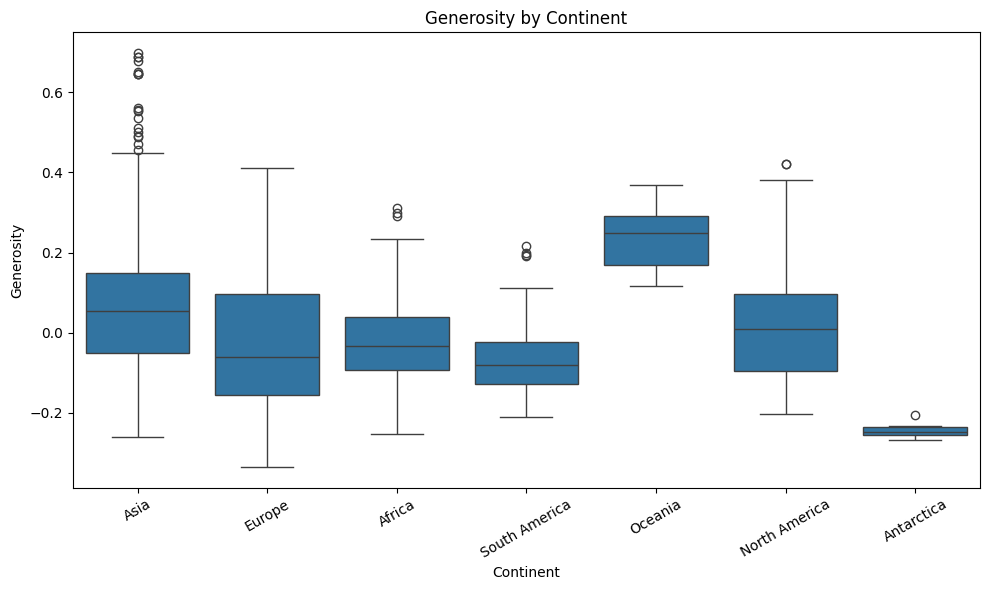

In [ ]:
# a. Relationship between Continent and Generosity
plt.figure(figsize=(10,6))
sns.boxplot(x='Continent', y='Generosity', data=report_df)
plt.title('Generosity by Continent')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


b.

In [ ]:
# b. Is there a relationship?
means = report_df.groupby('Continent')['Generosity'].mean().sort_values(ascending=False)
print(means)

print("""
Yes. Oceania and Asia have the highest average Generosity scores, while Antarctica,
South America and Africa have the lowest (even negative) average scores. The boxplot
in (a) also shows clearly different medians and spreads across continents, confirming
Generosity is not evenly distributed -- it depends on the continent.
""")


Continent
Oceania          0.240467
Asia             0.080030
North America    0.020350
Europe          -0.025005
Africa          -0.033315
South America   -0.066233
Antarctica      -0.245000
Name: Generosity, dtype: float64

Yes. Oceania and Asia have the highest average Generosity scores, while Antarctica,
South America and Africa have the lowest (even negative) average scores. The boxplot
in (a) also shows clearly different medians and spreads across continents, confirming
Generosity is not evenly distributed -- it depends on the continent.



# Excercise 5

For this exercise, we will be using whickham.csv. Draw the following described visualizations.

    a.	What is the numerical attribute in this dataset? Draw two different plots that summarize the population of data objects for the numerical attribute.
    b.	What are the categorical attributes in this dataset? Draw a plot per attribute that summarizes the population of the data object for each attribute. 
    c.	 Draw a visual that examine the relationship between outcome and smoker. Do you notice anything surprising about this visualization?
    d.	To demystify the surprising relationship you observed on c) run the following code, and study the visual it creates.

``
person_df = pd.read_csv('whickham.csv')
person_df['age_discretized'] = pd.cut(person_df.age, bins = 4, labels=False)
person_df.groupby(['age_discretized','smoker']).outcome.value_counts().unstack().unstack().plot.bar(stacked=True)
plt.show()
``

    e.	Using the visual that was created under d) explain the surprising observation under c).
    f.	How many dimensions the visual that was created under d) has? How did we manage to add dimensions to the bar chart?


In [ ]:
person_df = pd.read_csv('whickham.csv')
person_df.head()

,outcome,smoker,age
0,Alive,Yes,23
1,Alive,Yes,18
2,Dead,Yes,71
3,Alive,No,67
4,Alive,No,64


a.

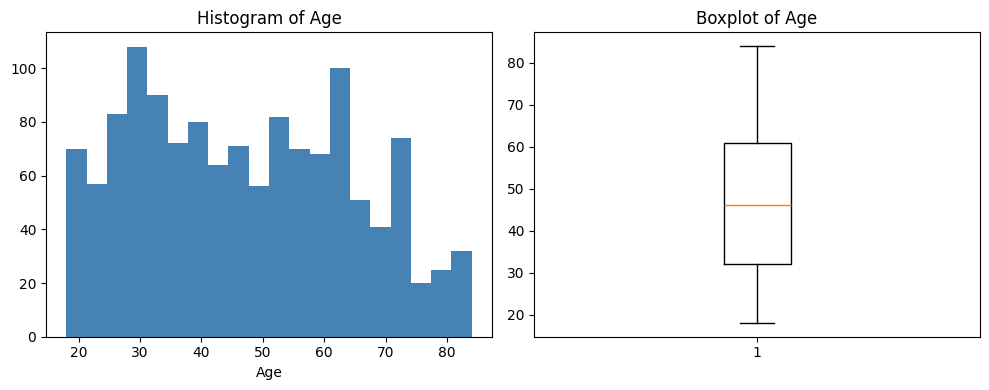

In [ ]:
# a. Numerical attribute = age -> two plots summarizing its distribution
fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].hist(person_df.age, bins=20, color='steelblue')
axes[0].set_title('Histogram of Age')
axes[0].set_xlabel('Age')

axes[1].boxplot(person_df.age)
axes[1].set_title('Boxplot of Age')
plt.tight_layout()
plt.show()


b.

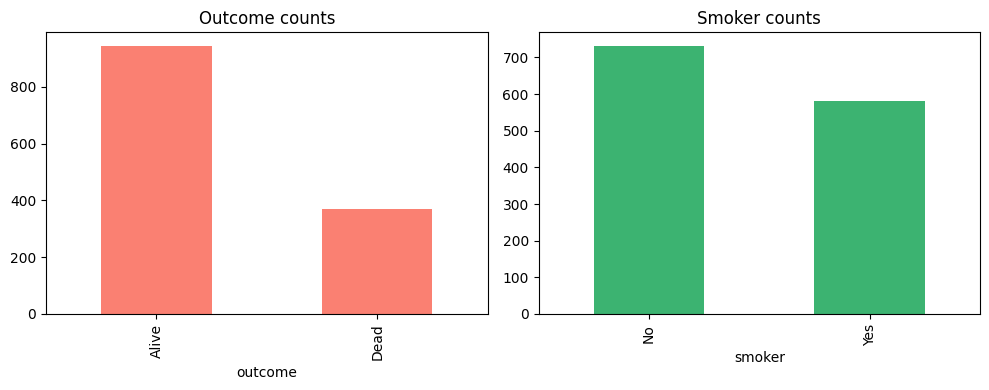

In [ ]:
# b. Categorical attributes = outcome, smoker -> one plot per attribute
fig, axes = plt.subplots(1, 2, figsize=(10,4))
person_df.outcome.value_counts().plot.bar(ax=axes[0], color='salmon')
axes[0].set_title('Outcome counts')

person_df.smoker.value_counts().plot.bar(ax=axes[1], color='mediumseagreen')
axes[1].set_title('Smoker counts')
plt.tight_layout()
plt.show()


c. 

outcome     Alive      Dead
smoker                     
No       0.685792  0.314208
Yes      0.761168  0.238832


<Figure size 600x500 with 0 Axes>

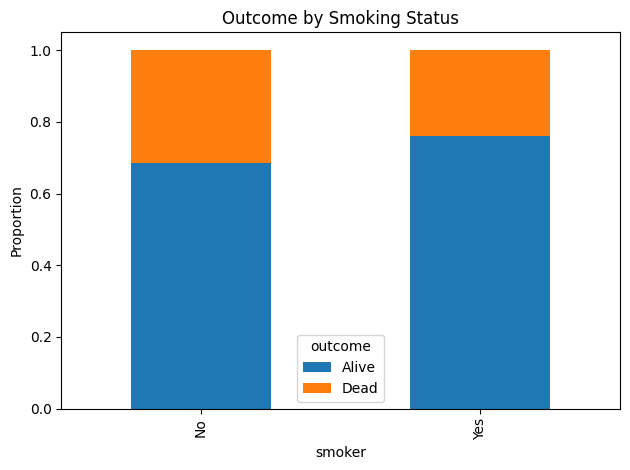


Surprising observation: smokers appear to have a HIGHER survival rate (~76%) than
non-smokers (~69%) -- the opposite of what we'd expect!



In [ ]:
# c. Relationship between outcome and smoker
prop = pd.crosstab(person_df.smoker, person_df.outcome, normalize='index')
print(prop)

plt.figure(figsize=(6,5))
prop.plot.bar(stacked=True)
plt.ylabel('Proportion')
plt.title('Outcome by Smoking Status')
plt.tight_layout()
plt.show()

print("""
Surprising observation: smokers appear to have a HIGHER survival rate (~76%) than
non-smokers (~69%) -- the opposite of what we'd expect!
""")


d. 

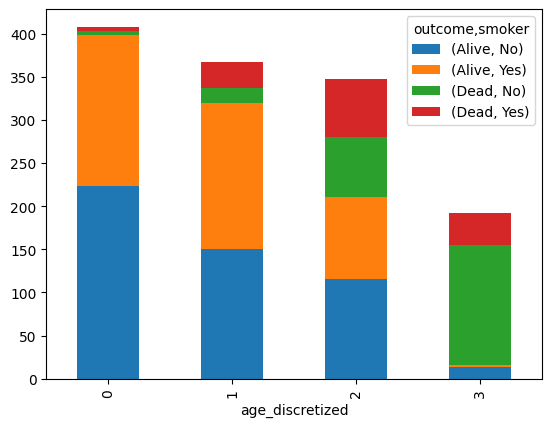

In [ ]:
# d. Provided code -- run as instructed
person_df['age_discretized'] = pd.cut(person_df.age, bins=4, labels=False)
person_df.groupby(['age_discretized','smoker']).outcome.value_counts().unstack().unstack().plot.bar(stacked=True)
plt.show()


e.

In [ ]:
# e. Explaining the surprising observation from c) using the chart in d)
print("""
Once we split by age group, within almost every age group non-smokers survive at a
similar or higher rate than smokers -- the surprising result in (c) disappears.
The original result was driven by AGE as a confounding variable: smokers in this
dataset were, on average, younger than non-smokers, and younger people are simply
more likely to still be alive regardless of smoking status. This is a classic
example of Simpson's Paradox.
""")



Once we split by age group, within almost every age group non-smokers survive at a
similar or higher rate than smokers -- the surprising result in (c) disappears.
The original result was driven by AGE as a confounding variable: smokers in this
dataset were, on average, younger than non-smokers, and younger people are simply
more likely to still be alive regardless of smoking status. This is a classic
example of Simpson's Paradox.



f.

In [ ]:
# f. How many dimensions does the chart in d) show?
print("""
The chart in (d) encodes FOUR dimensions of information:
1. Age group (age_discretized)  -> position along the x-axis
2. Smoker status (Yes/No)       -> a second grouping level on the x-axis
3. Outcome (Alive/Dead)         -> stacked segments within each bar
4. Count/frequency              -> the height of each stacked segment

We added dimensions beyond a simple bar chart by (1) grouping bars by a second
categorical variable (smoker) with groupby + unstack, and (2) stacking a third
categorical variable (outcome) within each bar using stacked=True.
""")



The chart in (d) encodes FOUR dimensions of information:
1. Age group (age_discretized)  -> position along the x-axis
2. Smoker status (Yes/No)       -> a second grouping level on the x-axis
3. Outcome (Alive/Dead)         -> stacked segments within each bar
4. Count/frequency              -> the height of each stacked segment

We added dimensions beyond a simple bar chart by (1) grouping bars by a second
categorical variable (smoker) with groupby + unstack, and (2) stacking a third
categorical variable (outcome) within each bar using stacked=True.



# Excercise 6

For this exercise, we will be using WH Report_preprocessed.csv. 

    a.	Use this dataset to create a 5-dimensional scatterplot to show the interactions between the following 5 attributes: year, Healthy_life_expectancy_at_birth, Social_support, Life_Ladder, population. Use the control bar for the “year”, marker size for population, marker color for Social_support, x-axis for Healthy_life_expectancy_at_birth, and y-axis for Life_Ladder.
    b.	Interact with and study the visual you created under a) and report your observations. 



In [ ]:
report_df = pd.read_csv('WH Report_preprocessed.csv')

a.

In [ ]:
# a. 5-dimensional interactive scatterplot
years = sorted(report_df.year.unique())

@interact(year=widgets.IntSlider(min=min(years), max=max(years), step=1, value=max(years)))
def plot_year(year):
    sub = report_df[report_df.year == year]
    plt.figure(figsize=(8,6))
    sc = plt.scatter(sub['Healthy_life_expectancy_at_birth'], sub['Life_Ladder'],
                      s=sub['population']/1e6, c=sub['Social_support'],
                      cmap='viridis', alpha=0.6, edgecolors='k')
    plt.colorbar(sc, label='Social support')
    plt.xlabel('Healthy life expectancy at birth')
    plt.ylabel('Life Ladder')
    plt.title(f'Year: {year}  (bubble size = population)')
    plt.show()


interactive(children=(IntSlider(value=2019, description='year', max=2019, min=2010), Output()), _dom_classes=(…

b. 

In [ ]:
# b. Observations from interacting with the visual
print("Correlation between Healthy life expectancy and Life Ladder:",
      round(report_df['Healthy_life_expectancy_at_birth'].corr(report_df['Life_Ladder']), 3))

print("""
Moving the year slider from 2010 to 2019, the overall positive relationship between
healthy life expectancy (x-axis) and Life Ladder (y-axis) stays consistent every year.
Larger bubbles (higher population) are concentrated among a few large Asian countries.
Countries with higher Social_support (brighter color) tend to cluster in the upper-right
of the chart, reinforcing that health, social support and happiness move together.
""")


Correlation between Healthy life expectancy and Life Ladder: 0.758

Moving the year slider from 2010 to 2019, the overall positive relationship between
healthy life expectancy (x-axis) and Life Ladder (y-axis) stays consistent every year.
Larger bubbles (higher population) are concentrated among a few large Asian countries.
Countries with higher Social_support (brighter color) tend to cluster in the upper-right
of the chart, reinforcing that health, social support and happiness move together.



# Excercise 7

For this exercise, we will continue using WH Report_preprocessed.csv. 

    a.	Create a visual that shows the trend of change for the attribute Generosity for all the countries in the dataset. To avoid making the visual overwhelming use the color grey for the line plots of all the countries, and don’t use a legend.
    b.	Add three more line plots to the previous visual using the color blue and a thicker line (linewidth=1.8) for the three countries, United States, China, and India. Work out the visual so it only shows you the legend of these three countries. The following screenshot shows the visual that is being described.



Figure 5. 23. Line plot comparing Generosity across all countries in 2010 and 2019 with emphasis on the United States, India, and China


    c.	Report your observations from the visual. Make sure to employ all of the line plots (grey and blue ones) in your observations 

a.

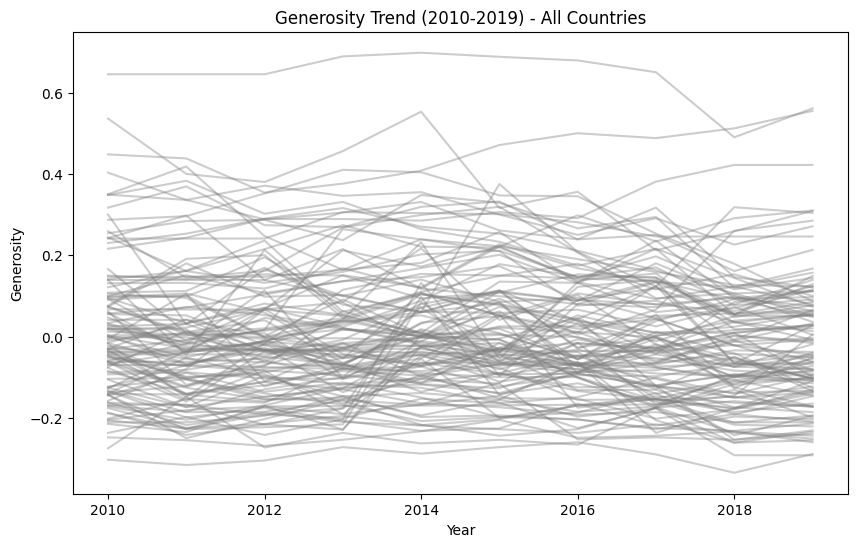

In [ ]:
# a. Trend of Generosity for all countries (grey, no legend)
plt.figure(figsize=(10,6))
for name, grp in report_df.groupby('Name'):
    plt.plot(grp.year, grp.Generosity, color='grey', alpha=0.4)
plt.xlabel('Year')
plt.ylabel('Generosity')
plt.title('Generosity Trend (2010-2019) - All Countries')
plt.show()


b.

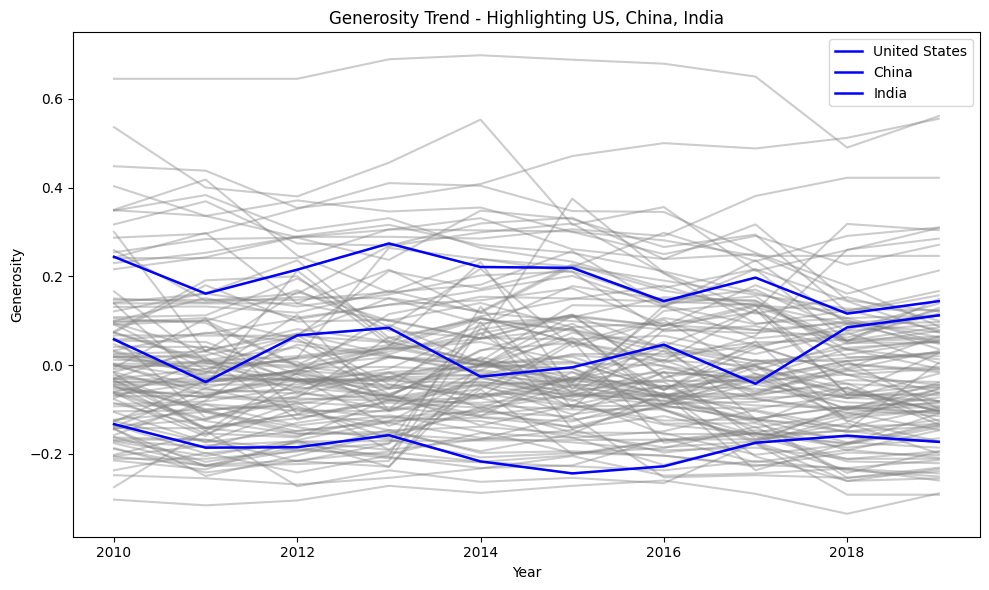

In [ ]:
# b. Highlight United States, China, India in blue
highlight = ['United States', 'China', 'India']

plt.figure(figsize=(10,6))
for name, grp in report_df.groupby('Name'):
    plt.plot(grp.year, grp.Generosity, color='grey', alpha=0.4)

for country in highlight:
    sub = report_df[report_df.Name == country]
    plt.plot(sub.year, sub.Generosity, color='blue', linewidth=1.8, label=country)

plt.xlabel('Year')
plt.ylabel('Generosity')
plt.title('Generosity Trend - Highlighting US, China, India')
plt.legend()
plt.tight_layout()
plt.show()


c.

In [ ]:
# c. Observations
print("""
Most countries (grey lines) hover close to zero with no strong universal trend over
the decade. Among the three highlighted countries:
- United States stays consistently ABOVE the global average, though it drifts down
  from ~0.24 (2010) to ~0.14 (2019).
- China stays consistently BELOW the global average and even below zero the whole
  decade (roughly -0.13 to -0.24), i.e. reported as "less generous than expected"
  given its GDP.
- India tracks close to the global average, fluctuating mildly between roughly
  -0.04 and +0.11 with a slight upward drift toward 2019.
""")



Most countries (grey lines) hover close to zero with no strong universal trend over
the decade. Among the three highlighted countries:
- United States stays consistently ABOVE the global average, though it drifts down
  from ~0.24 (2010) to ~0.14 (2019).
- China stays consistently BELOW the global average and even below zero the whole
  decade (roughly -0.13 to -0.24), i.e. reported as "less generous than expected"
  given its GDP.
- India tracks close to the global average, fluctuating mildly between roughly
  -0.04 and +0.11 with a slight upward drift toward 2019.

